<a href="https://colab.research.google.com/github/Latticceee/Graph-Theory-and-AI-in-Networks-Enhancement/blob/main/Graph_Theory_%26_AI_in_Networks_Enhancement_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

omarsaidlatticceee_griddataforisef_path = kagglehub.dataset_download('omarsaidlatticceee/griddataforisef')
omarsaidlatticceee_power_grid_v3_dataset_path = kagglehub.dataset_download('omarsaidlatticceee/power-grid-v3-dataset')

print('Data source import complete.')


# Power Grid GNN (v3) 1st place BASEF

This notebook includes the code used for producing the AI model that predicts the number of spanning trees thus used in enhancing electric networks. This project won 1st place at BASEF Competition in the Math Category.

Gemini 3 pro was used to polish the code and make it cleaner. Also, it helped a lot with errors , a co-author.

To view the project's poster, visit the following link: https://drive.google.com/file/d/1Zm3Q954yRdaspiHClpllby9uh1Wu9IaW/view?usp=sharing


In [ ]:
import sys
import subprocess
import importlib.util

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

def module_exists(module_name):
    return importlib.util.find_spec(module_name) is not None

packages_to_install = []

if not module_exists("torch_geometric"):
    packages_to_install.append("torch-geometric")

# Optional: uncomment only if you use SHAP cell
# if not module_exists("shap"):
#     packages_to_install.append("shap")

if packages_to_install:
    pip_install(packages_to_install)

print(" Environment ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.7 MB/s eta 0:00:00
 Environment ready.


In [ ]:
import os, random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch.optim.lr_scheduler import ReduceLROnPlateau

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

V3_DATASET_DIR = "/kaggle/input/datasets/omarsaidlatticceee/power-grid-v3-dataset/power_grid_master_dataset_v3.pt"
MASTER_DATA_PATH = os.path.join(V3_DATASET_DIR, "/kaggle/input/datasets/omarsaidlatticceee/power-grid-v3-dataset/power_grid_master_dataset_v3.pt")

MODEL_PATH = os.path.join(V3_DATASET_DIR, "/kaggle/input/datasets/omarsaidlatticceee/power-grid-v3-dataset/gnn_expert_model_v3.pth")


OUT_DIR = "/kaggle/working/replication_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("MASTER_DATA_PATH:", MASTER_DATA_PATH, "| exists:", os.path.exists(MASTER_DATA_PATH))
print("MODEL_PATH:", MODEL_PATH, "| exists:", os.path.exists(MODEL_PATH))
print("OUT_DIR:", OUT_DIR)

plt.rcParams.update({"figure.dpi": 120})

Device: cpu
MASTER_DATA_PATH: /kaggle/input/datasets/omarsaidlatticceee/power-grid-v3-dataset/power_grid_master_dataset_v3.pt | exists: True
MODEL_PATH: /kaggle/input/datasets/omarsaidlatticceee/power-grid-v3-dataset/gnn_expert_model_v3.pth | exists: True
OUT_DIR: /kaggle/working/replication_outputs


In [ ]:
if not os.path.exists(MASTER_DATA_PATH):
    raise FileNotFoundError(
        " Missing dataset file. Ensure you added the Kaggle Dataset that contains:\n"
        f"  {MASTER_DATA_PATH}\n"
        "If your dataset directory name is different, change V3_DATASET_DIR in Cell 1."
    )

all_data = torch.load(MASTER_DATA_PATH, weights_only=False)
print(f"✅ Loaded dataset samples: {len(all_data):,}")

d0 = all_data[0]
print("\n--- Single sample repr ---")
print(d0)

print("\n--- Shapes ---")
print("x:", tuple(d0.x.shape), " (node features)")
print("edge_index:", tuple(d0.edge_index.shape))
print("u:", tuple(d0.u.shape), " (operation features)")
print("y:", tuple(d0.y.shape), " (label)")

if d0.x.dim() != 2 or d0.x.shape[1] != 3:
    print(" Warning: expected node feature dim = 3. Found:", tuple(d0.x.shape))
if d0.u.dim() != 2 or d0.u.shape[1] != 11:
    print(" Warning: expected op feature dim = 11. Found:", tuple(d0.u.shape))

✅ Loaded dataset samples: 93,500

--- Single sample repr ---
Data(x=[662, 3], edge_index=[2, 1569], y=[1], u=[1, 11])

--- Shapes ---
x: (662, 3)  (node features)
edge_index: (2, 1569)
u: (1, 11)  (operation features)
y: (1,)  (label)


Scanning 8000 samples: 100%|██████████| 8000/8000 [00:00<00:00, 128179.94it/s]



===== STRUCTURE REPORT =====
scanned: 8000
bad_samples: 0
nodes_mean: 1001.027875
nodes_min: 494
nodes_max: 5300
edges_mean: 3070.942125
edges_min: 1079
edges_max: 13572
x_dim_set: [3]
u_dim_set: [11]
y_dim_set: [1]


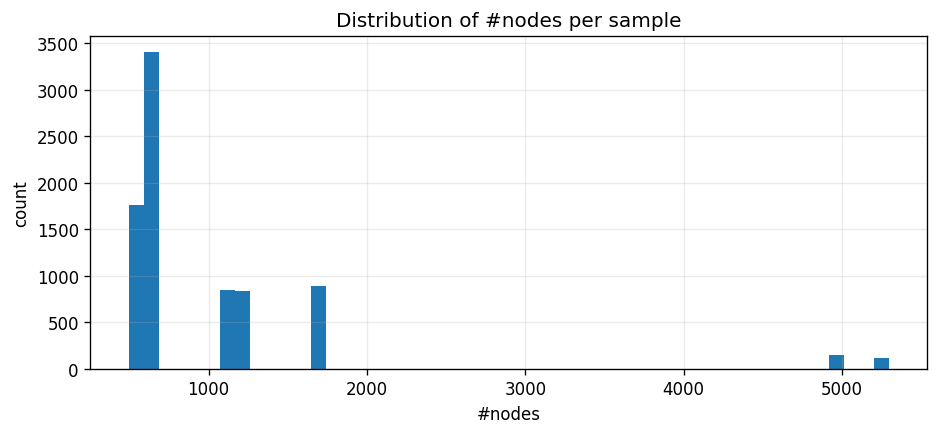

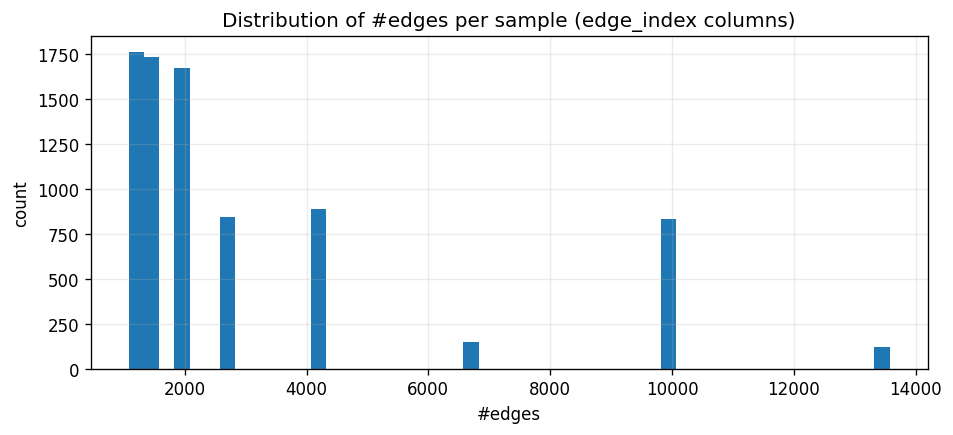

✅ Saved structure plots to: /kaggle/working/replication_outputs


In [ ]:
# Cell 3 — Dataset structure report (robust; scans a subset)
def dataset_structure_report(data_list, max_scan=8000):
    n = min(len(data_list), max_scan)
    nodes, edges = [], []
    x_dims, u_dims, y_dims = [], [], []
    bad = 0

    for i in tqdm(range(n), desc=f"Scanning {n} samples"):
        d = data_list[i]
        try:
            nodes.append(int(d.x.shape[0]))
            edges.append(int(d.edge_index.shape[1]))
            x_dims.append(int(d.x.shape[1]))
            u_dims.append(int(d.u.shape[1]))
            y_dims.append(int(d.y.numel()))
        except Exception:
            bad += 1

    report = {
        "scanned": n,
        "bad_samples": bad,
        "nodes_mean": float(np.mean(nodes)) if nodes else None,
        "nodes_min": int(np.min(nodes)) if nodes else None,
        "nodes_max": int(np.max(nodes)) if nodes else None,
        "edges_mean": float(np.mean(edges)) if edges else None,
        "edges_min": int(np.min(edges)) if edges else None,
        "edges_max": int(np.max(edges)) if edges else None,
        "x_dim_set": sorted(list(set(x_dims))),
        "u_dim_set": sorted(list(set(u_dims))),
        "y_dim_set": sorted(list(set(y_dims))),
    }
    return report, nodes, edges

report, nodes_list, edges_list = dataset_structure_report(all_data, max_scan=8000)

print("\n===== STRUCTURE REPORT =====")
for k, v in report.items():
    print(f"{k}: {v}")

if nodes_list:
    plt.figure(figsize=(9,3.6))
    plt.hist(nodes_list, bins=50)
    plt.title("Distribution of #nodes per sample")
    plt.xlabel("#nodes"); plt.ylabel("count")
    plt.grid(alpha=0.25)
    plt.savefig(os.path.join(OUT_DIR, "hist_nodes.png"), bbox_inches="tight")
    plt.show()

if edges_list:
    plt.figure(figsize=(9,3.6))
    plt.hist(edges_list, bins=50)
    plt.title("Distribution of #edges per sample (edge_index columns)")
    plt.xlabel("#edges"); plt.ylabel("count")
    plt.grid(alpha=0.25)
    plt.savefig(os.path.join(OUT_DIR, "hist_edges.png"), bbox_inches="tight")
    plt.show()

print("✅ Saved structure plots to:", OUT_DIR)

In [ ]:
# Cell 4 — Feature inspection: 3 node + 11 op + label (13 quantities total)
OP_FEATURE_NAMES = [
    "op_is_add",
    "deg(u)_base",
    "deg(v)_base",
    "density_base",
    "BC(u)_base",
    "BC(v)_base",
    "Clust(u)_base",
    "Clust(v)_base",
    "jaccard_base",
    "is_intercommunity",
    "shortest_path_len_base"
]
NODE_FEATURE_NAMES = ["degree_mod", "betweenness_base", "clustering_base"]

U, Y = [], []
limit = min(len(all_data), 15000)
for i in tqdm(range(limit), desc=f"Collecting op features (n={limit})"):
    d = all_data[i]
    U.append(d.u.squeeze().cpu().numpy())
    Y.append(float(d.y.squeeze().cpu().numpy()))
U = np.vstack(U)
Y = np.array(Y)

df_u = pd.DataFrame(U, columns=OP_FEATURE_NAMES)
df_u["label_y_logtau"] = Y

print("\n===== OP FEATURES (11) + LABEL =====")
display(df_u.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T)

node_rows = []
for i in tqdm(range(min(250, len(all_data))), desc="Collecting node features"):
    x = all_data[i].x.cpu().numpy()
    node_rows.append(x)
X = np.vstack(node_rows)
df_x = pd.DataFrame(X, columns=NODE_FEATURE_NAMES)

print("\n===== NODE FEATURES (3) =====")
display(df_x.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T)

idx = np.random.randint(0, len(all_data))
d = all_data[idx]
print("\n===== ONE EXAMPLE SAMPLE =====")
print("Sample index:", idx)
print("Label y = log τ(G'):", float(d.y))

print("\nOperation feature vector u (11 values):")
for name, val in zip(OP_FEATURE_NAMES, d.u.squeeze().tolist()):
    print(f"  {name:>20s}: {val:.6g}")

print("\nNode feature example (first 10 nodes, 3 values each):")
x = d.x[:10].cpu().numpy()
for i in range(min(10, x.shape[0])):
    print(f"node {i:>3d}: " + ", ".join([f"{NODE_FEATURE_NAMES[j]}={x[i,j]:.6g}" for j in range(3)]))


===== OP FEATURES (11) + LABEL =====


,count,mean,std,min,1%,5%,50%,95%,99%,max
op_is_add,15000.0,0.498933,0.500014,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
deg(u)_base,15000.0,8.004867,13.657309,1.000000,3.000000,3.000000,5.000000,19.000000,81.000000,100.000000
deg(v)_base,15000.0,8.498333,14.420587,1.000000,3.000000,3.000000,5.000000,22.050000,81.000000,100.000000
density_base,15000.0,0.007513,0.003288,0.000540,0.000540,0.002775,0.008396,0.014321,0.014321,0.014321
BC(u)_base,15000.0,0.016589,0.035810,0.000000,0.000000,0.000000,0.002965,0.085231,0.180870,0.436891
BC(v)_base,15000.0,0.016699,0.035648,0.000000,0.000000,0.000000,0.003229,0.081722,0.183414,0.436891
Clust(u)_base,15000.0,0.144694,0.291429,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
Clust(v)_base,15000.0,0.154426,0.301216,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
jaccard_base,15000.0,0.198066,0.320594,0.000000,0.000000,0.000000,0.000000,0.857143,0.965517,0.989899
is_intercommunity,15000.0,0.698133,0.459046,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000



===== NODE FEATURES (3) =====


,count,mean,std,min,1%,5%,50%,95%,99%,max
degree_mod,246967.0,6.104144,9.029482,1.0,1.0,3.0,4.000000,10.000000,60.000000,100.000000
betweenness_base,246967.0,0.011239,0.028550,0.0,0.0,0.0,0.001162,0.056156,0.153346,0.436891
clustering_base,246967.0,0.123688,0.273782,0.0,0.0,0.0,0.000000,1.000000,1.000000,1.000000



===== ONE EXAMPLE SAMPLE =====
Sample index: 15795
Label y = log τ(G'): 904.7876586914062

Operation feature vector u (11 values):
             op_is_add: 1
           deg(u)_base: 4
           deg(v)_base: 6
          density_base: 0.00277519
            BC(u)_base: 0.00331151
            BC(v)_base: 0.00434726
         Clust(u)_base: 0
         Clust(v)_base: 0.166667
          jaccard_base: 0
     is_intercommunity: 1
  shortest_path_len_base: 8

Node feature example (first 10 nodes, 3 values each):
node   0: degree_mod=3, betweenness_base=0, clustering_base=0
node   1: degree_mod=3, betweenness_base=0, clustering_base=0
node   2: degree_mod=3, betweenness_base=0, clustering_base=0
node   3: degree_mod=3, betweenness_base=0, clustering_base=0
node   4: degree_mod=3, betweenness_base=0, clustering_base=0
node   5: degree_mod=3, betweenness_base=0, clustering_base=0
node   6: degree_mod=3, betweenness_base=0, clustering_base=0
node   7: degree_mod=3, betweenness_base=0, clustering_ba

In [ ]:
# Cell 5 training
class SpanningTreeDataset(Dataset):
    def __init__(self, data_list):
        super().__init__()
        self.data_list = data_list
    def len(self): return len(self.data_list)
    def get(self, idx): return self.data_list[idx]

class SpanningTreeGNN(torch.nn.Module):
    def __init__(self, num_node_features=3, num_op_features=11, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.regressor = Sequential(
            Linear(hidden + num_op_features, 128), ReLU(), BatchNorm1d(128),
            Linear(128, 64), ReLU(), BatchNorm1d(64),
            Linear(64, 1)
        )
    def forward(self, data):
        x, edge_index, batch, u = data.x, data.edge_index, data.batch, data.u
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        g = global_mean_pool(x, batch)
        return self.regressor(torch.cat([g, u], dim=1)).squeeze(-1)

train_list, val_list = train_test_split(all_data, test_size=0.2, random_state=SEED)

train_loader = DataLoader(
    SpanningTreeDataset(train_list),
    batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    SpanningTreeDataset(val_list),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

model = SpanningTreeGNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
sched = ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
crit = torch.nn.MSELoss()

EPOCHS = 80
EARLY_PATIENCE = 12

best_val = float("inf")
pat = 0
ckpt_path = os.path.join(OUT_DIR, "best_model_state_dict.pth")
history = {"epoch":[], "train_mse":[], "val_mse":[], "lr":[]}

print("✅ Starting training...")
for epoch in range(1, EPOCHS+1):
    model.train()
    train_sum = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        batch = batch.to(device)
        opt.zero_grad(set_to_none=True)
        pred = model(batch)
        loss = crit(pred, batch.y.view(-1))
        loss.backward()
        opt.step()
        train_sum += loss.item() * batch.num_graphs
    train_mse = train_sum / len(train_loader.dataset)

    model.eval()
    val_sum = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]"):
            batch = batch.to(device)
            pred = model(batch)
            loss = crit(pred, batch.y.view(-1))
            val_sum += loss.item() * batch.num_graphs
    val_mse = val_sum / len(val_loader.dataset)

    lr = opt.param_groups[0]["lr"]
    history["epoch"].append(epoch)
    history["train_mse"].append(train_mse)
    history["val_mse"].append(val_mse)
    history["lr"].append(lr)

    print(f"Epoch {epoch:03d} | train MSE={train_mse:.4f} | val MSE={val_mse:.4f} | lr={lr:.2e}")
    sched.step(val_mse)

    if val_mse < best_val:
        best_val = val_mse
        pat = 0
        torch.save(model.state_dict(), ckpt_path)
        print(f"  ✓ saved new best: {best_val:.4f}")
    else:
        pat += 1

    if pat >= EARLY_PATIENCE:
        print(f"✅ Early stopping at epoch {epoch} (no improvement for {EARLY_PATIENCE} epochs)")
        break

print("Best val MSE:", best_val)
print("✅ Checkpoint saved to:", ckpt_path)

✅ Starting training...


Epoch 1/80 [val]: 100%|██████████| 585/585 [01:05<00:00,  8.92it/s]


Epoch 001 | train MSE=6246023.3448 | val MSE=6174606.9647 | lr=1.00e-04
  ✓ saved new best: 6174606.9647


Epoch 2/80 [val]: 100%|██████████| 585/585 [00:56<00:00, 10.41it/s]


Epoch 002 | train MSE=6120357.9007 | val MSE=6016414.3152 | lr=1.00e-04
  ✓ saved new best: 6016414.3152


...

Epoch 046 | train MSE=30321.0256 | val MSE=14649.1012 | lr=5.00e-05


Epoch 47/80 [val]: 100%|██████████| 585/585 [00:47<00:00, 12.41it/s]


Epoch 047 | train MSE=30279.6283 | val MSE=11647.7661 | lr=5.00e-05


Epoch 48/80 [val]: 100%|██████████| 585/585 [00:46<00:00, 12.50it/s]

Epoch 048 | train MSE=31322.0856 | val MSE=2228.6869 | lr=5.00e-05
✅ Early stopping at epoch 48 (no improvement for 12 epochs)
Best val MSE: 1470.6731562029997
Checkpoint saved to: /kaggle/working/replication_outputs/best_model_state_dict.pth


Predicting val set: 100%|██████████| 585/585 [00:53<00:00, 10.87it/s]


 Metrics | R2=0.9985 | RMSE=38.349 | MAE=30.915 | n=18,700


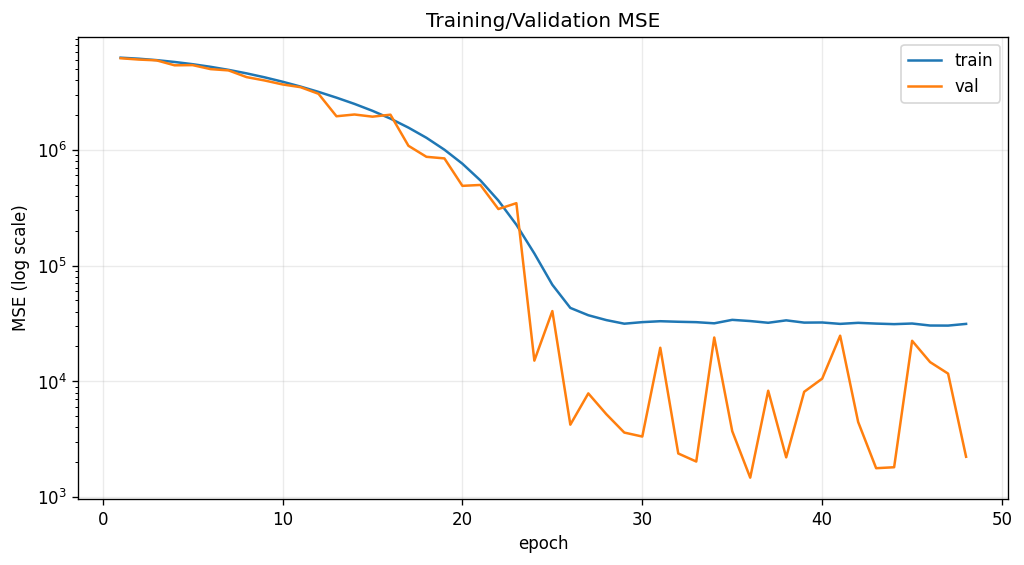

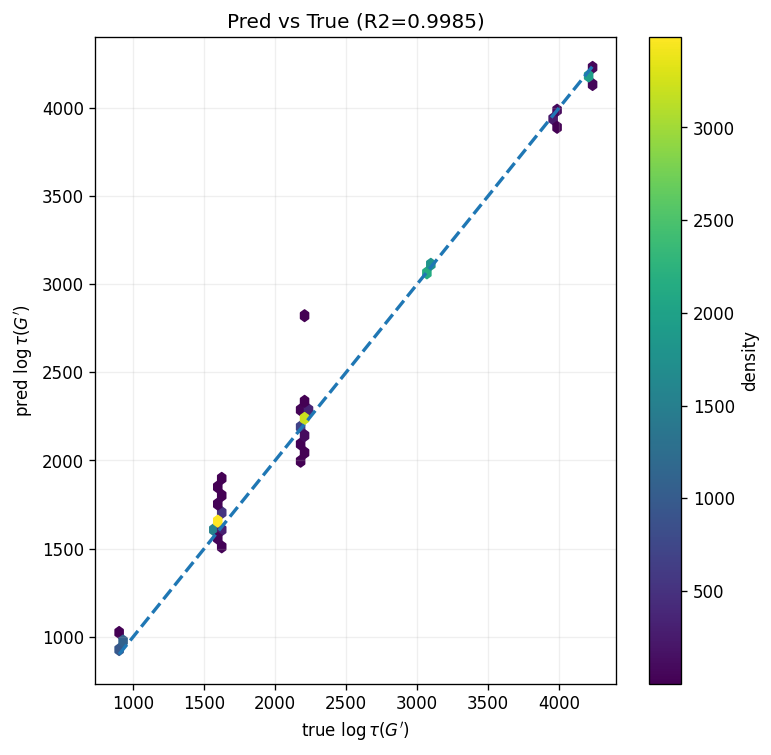

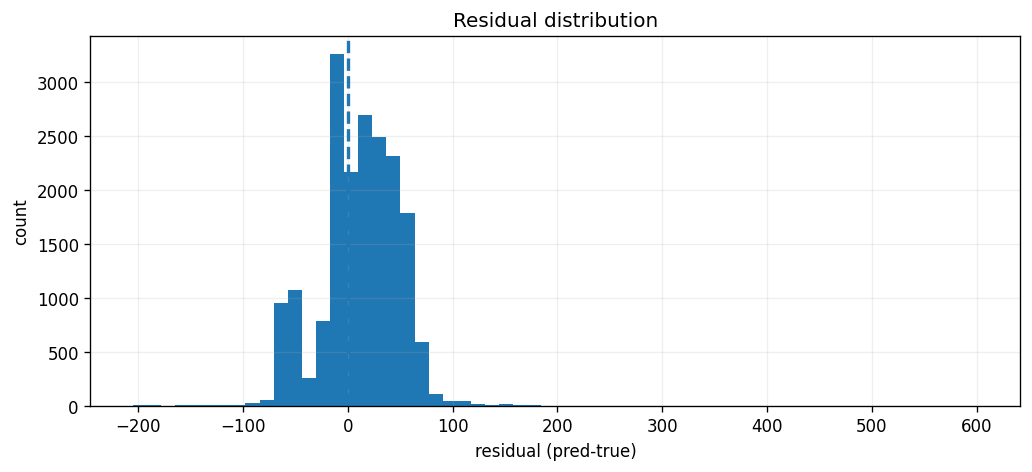

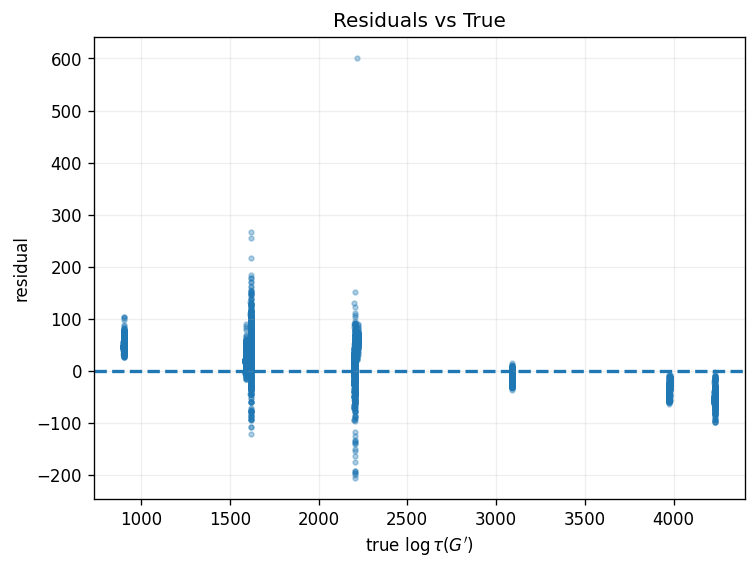

 Saved evaluation figures to: /kaggle/working/replication_outputs


In [ ]:
# Cell 6 figures
dfh = pd.DataFrame(history)

model_eval = SpanningTreeGNN().to(device)
model_eval.load_state_dict(torch.load(os.path.join(OUT_DIR, "best_model_state_dict.pth"), map_location=device))
model_eval.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Predicting val set"):
        batch = batch.to(device)
        pred = model_eval(batch).detach().cpu().numpy()
        y_pred.append(pred)
        y_true.append(batch.y.view(-1).detach().cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = float(np.sqrt(mse))
res = y_pred - y_true

print(f" Metrics | R2={r2:.4f} | RMSE={rmse:.3f} | MAE={mae:.3f} | n={len(y_true):,}")

# Figure 1
plt.figure(figsize=(10,5))
plt.plot(dfh["epoch"], dfh["train_mse"], label="train")
plt.plot(dfh["epoch"], dfh["val_mse"], label="val")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("MSE (log scale)")
plt.grid(alpha=0.25); plt.legend()
plt.title("Training/Validation MSE")
plt.savefig(os.path.join(OUT_DIR, "fig_train_curve.png"), dpi=250, bbox_inches="tight")
plt.show()

# Figure 2
plt.figure(figsize=(7,7))
hb = plt.hexbin(y_true, y_pred, gridsize=60, mincnt=1)
plt.colorbar(hb, label="density")
mn, mx = float(y_true.min()), float(y_true.max())
plt.plot([mn,mx],[mn,mx], "--", linewidth=2)
plt.xlabel(r"true $\log\tau(G')$")
plt.ylabel(r"pred $\log\tau(G')$")
plt.title(f"Pred vs True (R2={r2:.4f})")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(OUT_DIR, "fig_pred_vs_true.png"), dpi=250, bbox_inches="tight")
plt.show()

# Figure 3
plt.figure(figsize=(10,4))
plt.hist(res, bins=60)
plt.axvline(0, linestyle="--", linewidth=2)
plt.xlabel("residual (pred-true)")
plt.ylabel("count")
plt.title("Residual distribution")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(OUT_DIR, "fig_residual_hist.png"), dpi=250, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_true, res, s=8, alpha=0.35)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel(r"true $\log\tau(G')$")
plt.ylabel("residual")
plt.title("Residuals vs True")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(OUT_DIR, "fig_residual_scatter.png"), dpi=250, bbox_inches="tight")
plt.show()

print(" Saved evaluation figures to:", OUT_DIR)

In [ ]:
# Cell 7 pretrained model from dataset
if os.path.exists(MODEL_PATH):
    model_pre = SpanningTreeGNN().to(device)
    try:
        model_pre.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model_pre.eval()
        with torch.no_grad():
            batch = next(iter(val_loader)).to(device)
            _ = model_pre(batch)
        print(" Pretrained model loaded successfully and forward-pass works.")
    except Exception as e:
        print(" Could not load pretrained model state_dict cleanly.")
        print("   This does NOT affect training from scratch.")
        print("   Error:", repr(e))
else:
    print(" MODEL_PATH not found; skipping pretrained model check.")

 Pretrained model loaded successfully and forward-pass works.
